# Tutorial Scanpy-Squidpy Xenium Pancreas

https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_xenium.html#analyze-xenium-data

In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

env: ANYWIDGET_HMR=1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import scanpy as sc
import squidpy as sq
import spatialdata as sd

import celldega as dega

from spatialdata_io import xenium

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources im

In [3]:
xenium_path = 'data/xenium_data/Xenium_V1_human_Pancreas_FFPE_outs/'
zarr_path = 'data/Xenium_V1_human_Pancreas_FFPE_outs.zarr'

# Pre-Process, Cluster, and UMAP

In [4]:
sdata = xenium(xenium_path)

INFO     reading data/xenium_data/Xenium_V1_human_Pancreas_FFPE_outs/cell_feature_matrix.h5                        


/var/folders/8d/jxpy9rd10j7fp2rcj_s5sz3c0000gq/T/ipykernel_8945/1221898808.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = xenium(xenium_path)


In [5]:
adata = sdata.tables["table"]
adata

AnnData object with n_obs × n_vars = 140702 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [6]:
del sdata

### Calculate QC Metrics

In [9]:
# sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)
# cprobes = (
#     adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
# )
# cwords = (
#     adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
# )
# print(f"Negative DNA probe count % : {cprobes}")
# print(f"Negative decoding count % : {cwords}")

In [10]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [11]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

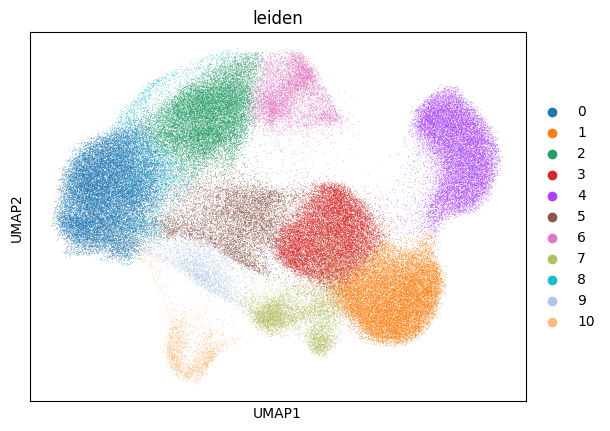

In [9]:
sc.pl.umap(
    adata,
    color=[

        "leiden",
    ],
    wspace=0.4,
)

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


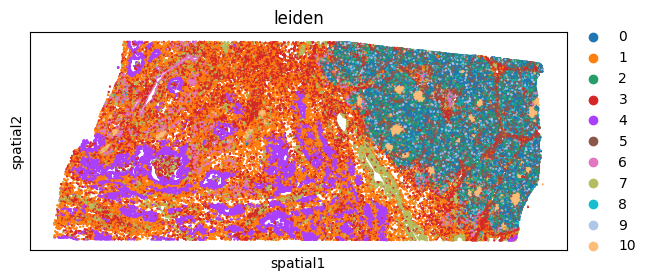

In [10]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

In [21]:
# adata.write_h5ad('data/xenium_data/Xenium_V1_human_Pancreas_FFPE_outs.h5ad')

# Load Pre-calc Clustering and UMAP Results

In [4]:
adata = sc.read_h5ad('data/xenium_data/Xenium_V1_human_Pancreas_FFPE_outs.h5ad')

In [5]:
adata

AnnData object with n_obs × n_vars = 122678 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels', 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [6]:
base_url = 'https://raw.githubusercontent.com/broadinstitute/celldega_Xenium_human_Pancreas_FFPE/main/Landscape_Xenium_V1_human_Pancreas_FFPE_outs_webp'

In [24]:
landscape = dega.viz.Landscape(
    technology='Xenium', 
    base_url = base_url,
    height=600,
    adata=adata,
    landscape_state='umap'
)

In [25]:
mat = dega.clust.Matrix(adata, row_attr=['n_cells'], col_attr=['cell_area'])
mat.downsample_to(category='leiden')
mat.norm(axis='row', by='zscore')
mat.clust()
cgm = dega.viz.Clustergram(matrix=mat, width=500, height=500)

/Users/feni/Documents/celldega/src/celldega/clust/matrix.py:194: UserWarning: Large matrix (122678 x 377). Consider filtering.
  self.load_adata(data, col_attr=col_attr, row_attr=row_attr)


In [27]:
dega.viz.landscape_clustergram(landscape, cgm)

## Squidpy

In [10]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

In [11]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

  0%|          | 0/1000 [00:00<?, ?/s]

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources im

In [12]:
# Extract the z-score matrix from Squidpy output
z = adata.uns["leiden_nhood_enrichment"]["zscore"]

# Convert it to a DataFrame with labeled index and columns
df = pd.DataFrame(
    z,
    index=adata.obs["leiden"].cat.categories,
    columns=adata.obs["leiden"].cat.categories,
)


In [13]:
mat_sq = dega.clust.Matrix(df)
mat_sq.clust()
cgm_sq = dega.viz.Clustergram(matrix=mat_sq, width=500, height=500)

In [14]:
dega.viz.landscape_clustergram(landscape, cgm_sq)